# HAcs 409 — Financial Engineering and Capital Markets
## Individual Assignment: Derivative Pricing

**Students:** A, B and C

**Base case:** $S_0=100$, $K=100$, $r=5\%$ continuously compounded, $T=0.25$ years, $\sigma=20\%$, no dividends.

> Run **Restart/Kernel → Run All** before exporting the executed notebook to HTML/PDF.

## Imports and common parameters

### Rounding convention

**All option prices displayed in the results are rounded to the nearest cent (2 decimal places). Full numerical precision is retained internally for calculations. Intermediate tree values and Greeks may be shown at additional precision where useful for working.**


In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

S0, K0, r, T, sigma, q = 100., 100., .05, .25, .20, 0.

def bs(S,K,r,T,sigma,q=0.,option="call"):
    d1=(np.log(S/K)+(r-q+.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)
    if option=="call":
        return S*np.exp(-q*T)*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2)-S*np.exp(-q*T)*norm.cdf(-d1)

# Q1 — Basic derivative concepts

A derivative is a financial contract whose value depends on an underlying asset or variable. A call gives the holder the right, not the obligation, to buy at the strike; a put gives the right to sell. A European option is exercisable only at maturity, while an American option can be exercised up to maturity. The main pricing inputs are the underlying price, strike, volatility, interest rate, time to maturity and dividends/carry.

# Q2 — Payoffs

European call: $C_T=\max(S_T-K,0)$.

European put: $P_T=\max(K-S_T,0)$.

In [87]:
ST=np.array([80,90,100,110,120])
pd.DataFrame({"S_T":ST,"Call payoff":np.maximum(ST-K0,0),
              "Put payoff":np.maximum(K0-ST,0)})

,S_T,Call payoff,Put payoff
0,80,0.00,20.00
1,90,0.00,10.00
2,100,0.00,0.00
3,110,10.00,0.00
4,120,20.00,0.00


# Q3 — Put-call parity

For a non-dividend-paying stock:
$$C-P=S_0-Ke^{-rT}.$$
Equivalently, $C+Ke^{-rT}=P+S_0$. This follows because the two portfolios have identical terminal payoffs.

In [88]:
parity=S0-K0*np.exp(-r*T)
pd.DataFrame({"Quantity":["S0-K exp(-rT)"],"Value":[parity]})

,Quantity,Value
0,S0-K exp(-rT),1.24


# Q4 — Black-Scholes benchmark

In [89]:
bs_call=bs(S0,K0,r,T,sigma,q,"call")
bs_put=bs(S0,K0,r,T,sigma,q,"put")
pd.DataFrame({"Option":["European Call","European Put"], "Price":[round(bs_call,2),round(bs_put,2)]})

,Option,Price
0,European Call,4.61
1,European Put,3.37


# Q5 — CRR binomial European option

$u=e^{\sigma\sqrt{\Delta t}}$, $d=1/u$, and
$p=(e^{r\Delta t}-d)/(u-d)$. Values are discounted backwards from maturity.

In [90]:
def crr_eur(S,K,r,T,sig,N,opt):
    dt=T/N; u=np.exp(sig*np.sqrt(dt)); d=1/u
    p=(np.exp(r*dt)-d)/(u-d); disc=np.exp(-r*dt)
    j=np.arange(N+1); ST=S*u**j*d**(N-j)
    V=np.maximum(ST-K,0) if opt=="call" else np.maximum(K-ST,0)
    for n in range(N,0,-1): V=disc*(p*V[1:n+1]+(1-p)*V[:n])
    return V[0]

Nbin=500
ce=crr_eur(S0,K0,r,T,sigma,Nbin,"call")
pe=crr_eur(S0,K0,r,T,sigma,Nbin,"put")
pd.DataFrame({"Option":["European Call","European Put"], "Price":[round(ce,2),round(pe,2)]})

,Option,Price
0,European Call,4.61
1,European Put,3.37


# Q6 — CRR Greeks

Delta is obtained from the first tree step. Vega is estimated using a central finite difference.

In [91]:
def crr_eur_delta(S,K,r,T,sig,N,opt):
    dt=T/N; u=np.exp(sig*np.sqrt(dt)); d=1/u
    p=(np.exp(r*dt)-d)/(u-d); disc=np.exp(-r*dt)
    j=np.arange(N+1); ST=S*u**j*d**(N-j)
    V=np.maximum(ST-K,0) if opt=="call" else np.maximum(K-ST,0)
    for n in range(N,1,-1): V=disc*(p*V[1:n+1]+(1-p)*V[:n])
    delta=(V[1]-V[0])/(S*u-S*d)
    price=disc*(p*V[1]+(1-p)*V[0])
    return price,delta

c,dc=crr_eur_delta(S0,K0,r,T,sigma,Nbin,"call")
p,dp=crr_eur_delta(S0,K0,r,T,sigma,Nbin,"put")
h=.0001
vega_call=(crr_eur(S0,K0,r,T,sigma+h,Nbin,"call")-crr_eur(S0,K0,r,T,sigma-h,Nbin,"call"))/(2*h)
vega_put=(crr_eur(S0,K0,r,T,sigma+h,Nbin,"put")-crr_eur(S0,K0,r,T,sigma-h,Nbin,"put"))/(2*h)
pd.DataFrame({"Option":["European Call","European Put"],"Price":[c,p],
              "Delta":[dc,dp],"Vega":[vega_call,vega_put]})

,Option,Price,Delta,Vega
0,European Call,4.61,0.57,19.63
1,European Put,3.37,-0.43,19.63


# Q7 — American options with CRR

At each node the value is the maximum of continuation value and immediate exercise value.

In [92]:
def crr_amer(S,K,r,T,sig,N,opt):
    dt=T/N; u=np.exp(sig*np.sqrt(dt)); d=1/u
    p=(np.exp(r*dt)-d)/(u-d); disc=np.exp(-r*dt)
    j=np.arange(N+1); ST=S*u**j*d**(N-j)
    V=np.maximum(ST-K,0) if opt=="call" else np.maximum(K-ST,0)
    for n in range(N,0,-1):
        cont=disc*(p*V[1:n+1]+(1-p)*V[:n])
        j=np.arange(n); Sn=S*u**j*d**(n-j)
        ex=np.maximum(Sn-K,0) if opt=="call" else np.maximum(K-Sn,0)
        V=np.maximum(cont,ex)
    return V[0]
ac=crr_amer(S0,K0,r,T,sigma,Nbin,"call")
ap=crr_amer(S0,K0,r,T,sigma,Nbin,"put")
pd.DataFrame({"Option":["American Call","American Put"], "Price":[round(ac,2),round(ap,2)]})

,Option,Price
0,American Call,4.61
1,American Put,3.68


# Q8 — European versus American

With no dividends, the American call equals the European call. The American put can be more valuable because early exercise can be optimal when the stock price is sufficiently low.

In [93]:
pd.DataFrame({"Option":["European Call","American Call","European Put","American Put"], "Price":[round(ce,2),round(ac,2),round(pe,2),round(ap,2)]})

,Option,Price
0,European Call,4.61
1,American Call,4.61
2,European Put,3.37
3,American Put,3.68


# Q9 — Trinomial tree

In [94]:
def tri(S,K,r,T,sig,N,opt):
    dt=T/N; u=np.exp(sig*np.sqrt(2*dt)); d=1/u
    a=np.exp(r*dt/2); b=np.exp(sig*np.sqrt(dt/2)); cc=np.exp(-sig*np.sqrt(dt/2))
    pu=((a-cc)/(b-cc))**2; pd=((b-a)/(b-cc))**2; pm=1-pu-pd
    V=np.maximum(S*u**np.arange(-N,N+1)-K,0) if opt=="call" else np.maximum(K-S*u**np.arange(-N,N+1),0)
    disc=np.exp(-r*dt)
    for n in range(N,0,-1): V=disc*(pd*V[:-2]+pm*V[1:-1]+pu*V[2:])
    return V[0]

strikes=np.array([90,95,100,105,110])
rows=[]
for k in strikes: rows.append([k,tri(S0,k,r,T,sigma,500,"call"),tri(S0,k,r,T,sigma,500,"put")])
tri_df=pd.DataFrame(rows,columns=["Strike","Call","Put"])
tri_df["Call (2 d.p.)"]=tri_df.Call.round(2); tri_df["Put (2 d.p.)"]=tri_df.Put.round(2)
tri_df

,Strike,Call,Put,Call (2 d.p.),Put (2 d.p.)
0,90,11.67,0.55,11.67,0.55
1,95,7.71,1.53,7.71,1.53
2,100,4.61,3.37,4.61,3.37
3,105,2.48,6.17,2.48,6.17
4,110,1.19,9.82,1.19,9.82


# Q10 — Trinomial results, parity and European/American comparison

Calls decrease as strike rises and puts increase. The ATM values satisfy put-call parity up to numerical error. The American put has an early-exercise premium; the American call is essentially equal to the European call without dividends.

In [95]:
rows=[]
for k in strikes:
    rows.append([k,tri(S0,k,r,T,sigma,500,"call"),tri(S0,k,r,T,sigma,500,"put"),
                 crr_amer(S0,k,r,T,sigma,500,"call"),crr_amer(S0,k,r,T,sigma,500,"put")])
curve=pd.DataFrame(rows,columns=["Strike","European Call","European Put","American Call","American Put"])
curve.round(2)

,Strike,European Call,European Put,American Call,American Put
0,90,11.67,0.55,11.67,0.61
1,95,7.71,1.53,7.72,1.69
2,100,4.61,3.37,4.61,3.68
3,105,2.48,6.17,2.48,6.72
4,110,1.19,9.82,1.19,10.71


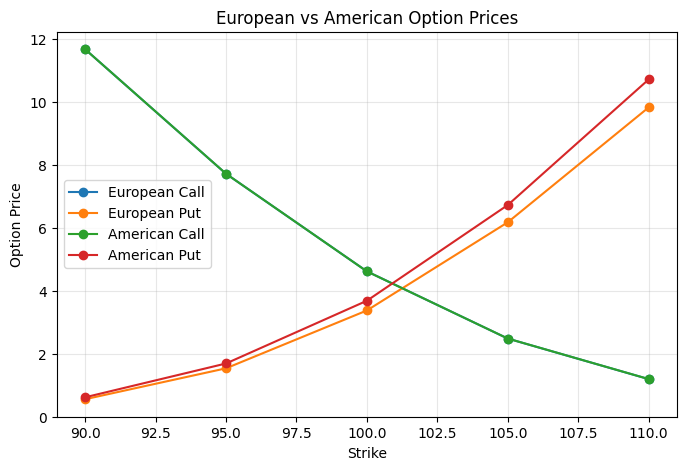

In [96]:
plt.figure(figsize=(8,5))
for col in curve.columns[1:]: plt.plot(curve["Strike"],curve[col],marker="o",label=col)
plt.xlabel("Strike"); plt.ylabel("Option Price"); plt.title("European vs American Option Prices")
plt.legend(); plt.grid(True,alpha=.3); plt.show()

# Q11 — Heston stochastic-volatility model

The Heston model uses stochastic variance:
$dS=rSdt+\sqrt vS\,dW^S$ and
$dv=\kappa(\theta-v)dt+\xi\sqrt v\,dW^v$, with correlation $\rho$. Full-truncation Euler keeps the variance used in square roots non-negative.

In [97]:
def heston_paths(S,r,T,v0,kappa,theta,xi,rho,n_paths,n_steps,seed=2026,paths=False):
    rng=np.random.default_rng(seed); dt=T/n_steps; sq=np.sqrt(dt)
    Sarr=np.full(n_paths,S,float); var=np.full(n_paths,v0,float)
    hist=np.empty((n_paths,n_steps+1)) if paths else None
    if paths: hist[:,0]=Sarr
    for t in range(n_steps):
        z1=rng.standard_normal(n_paths); z2=rng.standard_normal(n_paths)
        zv=rho*z1+np.sqrt(1-rho**2)*z2
        vp=np.maximum(var,0)
        var=np.maximum(vp+kappa*(theta-vp)*dt+xi*np.sqrt(vp)*sq*zv,0)
        Sarr*=np.exp((r-.5*vp)*dt+np.sqrt(vp)*sq*z1)
        if paths: hist[:,t+1]=Sarr
    return (Sarr,hist) if paths else Sarr

v0=sigma**2; kappa=1.85; theta=v0; xi=.35
hr=[]
for rho in [-.30,-.70]:
    ST=heston_paths(S0,r,T,v0,kappa,theta,xi,rho,200000,120)
    hr.append([rho,np.exp(-r*T)*np.mean(np.maximum(ST-K0,0)),
               np.exp(-r*T)*np.mean(np.maximum(K0-ST,0))])
heston=pd.DataFrame(hr,columns=["rho","Call","Put"])
heston["Call (2 d.p.)"]=heston.Call.round(2); heston["Put (2 d.p.)"]=heston.Put.round(2)
heston

,rho,Call,Put,Call (2 d.p.),Put (2 d.p.)
0,-0.30,4.57,3.29,4.57,3.29
1,-0.70,4.60,3.31,4.60,3.31


# Q12 — Heston Greeks

Central finite differences with common random numbers are used for Delta and Gamma.

In [98]:
def hprice(S,K,rho,opt,seed=2026,n=100000):
    ST=heston_paths(S,r,T,v0,kappa,theta,xi,rho,n,120,seed)
    payoff=np.maximum(ST-K,0) if opt=="call" else np.maximum(K-ST,0)
    return np.exp(-r*T)*payoff.mean()
hg=[]
for rho in [-.30,-.70]:
    for opt in ["call","put"]:
        vm=hprice(S0-.25,K0,rho,opt); v=hprice(S0,K0,rho,opt); vp=hprice(S0+.25,K0,rho,opt)
        hg.append([rho,opt,v,(vp-vm)/.5,(vp-2*v+vm)/.25**2])
pd.DataFrame(hg,columns=["rho","Option","Price","Delta","Gamma"]).round(4)

,rho,Option,Price,Delta,Gamma
0,-0.30,call,4.54,0.60,0.04
1,-0.30,put,3.30,-0.40,0.04
2,-0.70,call,4.56,0.62,0.04
3,-0.70,put,3.32,-0.38,0.04


# Q13 — Merton jump-diffusion

The risk-neutral drift is adjusted by the jump compensator $\kappa_J=E[J-1]$.

In [99]:
def merton_ST(S,r,T,sig,lam,muJ,sigJ,n,seed=2026):
    rng=np.random.default_rng(seed); N=rng.poisson(lam*T,n); Z=rng.standard_normal(n)
    jz=np.zeros(n); idx=np.where(N>0)[0]
    if len(idx): jz[idx]=rng.standard_normal(len(idx))*np.sqrt(N[idx])
    kJ=np.exp(muJ+.5*sigJ**2)-1
    return S*np.exp((r-lam*kJ-.5*sig**2)*T+sig*np.sqrt(T)*Z+N*muJ+sigJ*jz)

mr=[]
for lam in [.75,.25]:
    ST=merton_ST(S0,r,T,sigma,lam,-.5,.22,300000)
    mr.append([lam,np.exp(-r*T)*np.mean(np.maximum(ST-K0,0)),
               np.exp(-r*T)*np.mean(np.maximum(K0-ST,0))])
merton=pd.DataFrame(mr,columns=["Lambda","Call","Put"])
merton["Call (2 d.p.)"]=merton.Call.round(2); merton["Put (2 d.p.)"]=merton.Put.round(2)
merton

,Lambda,Call,Put,Call (2 d.p.),Put (2 d.p.)
0,0.75,8.14,6.89,8.14,6.89
1,0.25,5.73,4.49,5.73,4.49


# Q14 — Merton Greeks

In [100]:
def mprice(S,K,lam,opt,n=150000,seed=2026):
    rng=np.random.default_rng(seed); N=rng.poisson(lam*T,n); Z=rng.standard_normal(n)
    jz=np.zeros(n); idx=np.where(N>0)[0]
    if len(idx): jz[idx]=rng.standard_normal(len(idx))*np.sqrt(N[idx])
    muJ=-.5; sigJ=.22; kJ=np.exp(muJ+.5*sigJ**2)-1
    ST=S*np.exp((r-lam*kJ-.5*sigma**2)*T+sigma*np.sqrt(T)*Z+N*muJ+sigJ*jz)
    payoff=np.maximum(ST-K,0) if opt=="call" else np.maximum(K-ST,0)
    return np.exp(-r*T)*payoff.mean()
mg=[]
for lam in [.75,.25]:
    for opt in ["call","put"]:
        vm=mprice(S0-.25,K0,lam,opt); v=mprice(S0,K0,lam,opt); vp=mprice(S0+.25,K0,lam,opt)
        mg.append([lam,opt,v,(vp-vm)/.5,(vp-2*v+vm)/.25**2])
pd.DataFrame(mg,columns=["Lambda","Option","Price","Delta","Gamma"]).round(4)

,Lambda,Option,Price,Delta,Gamma
0,0.75,call,8.18,0.73,0.03
1,0.75,put,6.81,-0.27,0.03
2,0.25,call,5.74,0.64,0.04
3,0.25,put,4.47,-0.36,0.04


# Q15 — Put-call parity under Merton

Put-call parity remains valid for European options when the model is risk-neutral and there are no dividends. Monte Carlo results differ slightly because of simulation error.

In [101]:
pd.DataFrame([[lam,*merton.loc[merton.Lambda==lam,["Call","Put"]].iloc[0].tolist(),
                    merton.loc[merton.Lambda==lam,"Call"].iloc[0]-merton.loc[merton.Lambda==lam,"Put"].iloc[0],
                    parity] for lam in [.75,.25]],
                  columns=["Lambda","Call","Put","Call-Put","Parity RHS"]).round(4)

,Lambda,Call,Put,Call-Put,Parity RHS
0,0.75,8.14,6.89,1.26,1.24
1,0.25,5.73,4.49,1.24,1.24


# Q16 — Moneyness and smile comparison

Use $S/K=0.85,0.90,0.95,1.00,1.05,1.10,1.15$, so $K=S_0/(S/K)$. The graph is **option price versus strike** for Heston ($\rho=-0.70$), Merton and the constant-volatility Black-Scholes baseline.

In [102]:
moneyness=np.array([.85,.90,.95,1,1.05,1.10,1.15]); Kg=S0/moneyness
STh=heston_paths(S0,r,T,v0,kappa,theta,xi,-.70,250000,120)

# Updated Merton parameters for Q16
muJ_merton = -0.5
sigJ_merton = 0.22
lambda_merton = 0.75 # Assuming lambda=0.75 as used in previous Merton examples for STm

STm=merton_ST(S0,r,T,sigma,lambda_merton,muJ_merton,sigJ_merton,400000)
rows=[]
for m,k in zip(moneyness,Kg):
    rows.append([m,k,np.exp(-r*T)*np.mean(np.maximum(STh-k,0)),
                 np.exp(-r*T)*np.mean(np.maximum(STm-k,0)),bs(S0,k,r,T,sigma,q,"call")])
smile=pd.DataFrame(rows,columns=["S/K","Strike","Heston Call","Merton Call","BS Call"])
smile.round(2)

,S/K,Strike,Heston Call,Merton Call,BS Call
0,0.85,117.65,0.10,1.14,0.32
1,0.90,111.11,0.62,2.71,1.00
2,0.95,105.26,2.09,5.11,2.39
3,1.00,100.00,4.58,8.15,4.61
4,1.05,95.24,7.73,11.49,7.55
5,1.10,90.91,11.16,14.84,10.90
6,1.15,86.96,14.61,18.06,14.38


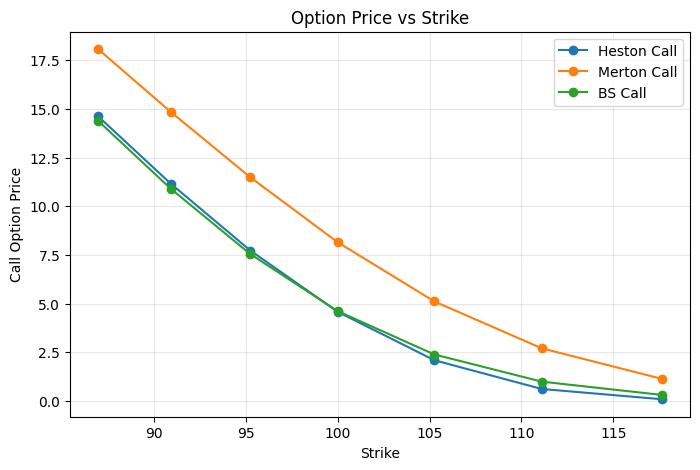

In [103]:
plt.figure(figsize=(8,5))
for col in ["Heston Call","Merton Call","BS Call"]:
    plt.plot(smile.Strike,smile[col],marker="o",label=col)
plt.xlabel("Strike"); plt.ylabel("Call Option Price"); plt.title("Option Price vs Strike")
plt.legend(); plt.grid(True,alpha=.3); plt.show()

### Q16 interpretation

Black-Scholes assumes one constant volatility and a lognormal terminal distribution. Heston adds stochastic volatility and return/variance correlation, while Merton adds jumps. These features alter tail probabilities and therefore produce prices that depart from the constant-volatility benchmark. Negative Heston correlation is especially important for the equity-style skew.

# Q17 — American call under Heston

For a non-dividend-paying stock, early exercise of an American call is not optimal under the standard assumptions. Therefore the American Heston call equals the European Heston call. Its Delta and Gamma are the corresponding European Heston estimates.

In [104]:
heston[heston.rho==-.70][["rho","Call","Put"]].round(4)

,rho,Call,Put
1,-0.70,4.60,3.31


In [105]:
def lsmc_am_call_h(S0,K,r,T,v0,k,th,xi,rho,n_paths=10000,n_steps=50,seed=123):
    rng=np.random.default_rng(seed); dt=T/n_steps
    S=np.zeros((n_paths,n_steps+1)); S[:,0]=S0
    v=np.full(n_paths,v0)
    for t in range(n_steps):
        vp=np.maximum(v,0)
        z1=rng.standard_normal(n_paths); z2=rng.standard_normal(n_paths)
        zv=rho*z1+np.sqrt(1-rho**2)*z2
        v=np.maximum(vp+k*(th-vp)*dt+xi*np.sqrt(vp*dt)*zv,0)
        S[:,t+1]=S[:,t]*np.exp((r-0.5*vp)*dt+np.sqrt(vp*dt)*z1)
    po=np.maximum(S-K,0); cash=po[:,-1].copy(); tex=np.full(n_paths,n_steps)
    for t in range(n_steps-1,0,-1):
        itm=po[:,t]>0
        if np.any(itm):
            X=S[itm,t]; Y=cash[itm]*np.exp(-r*(tex[itm]-t)*dt)
            A=np.vstack([np.ones_like(X),X,X**2]).T
            cf=np.linalg.lstsq(A,Y,rcond=None)[0]
            do=po[itm,t] > A@cf
            idx=np.where(itm)[0][do]; cash[idx]=po[idx,t]; tex[idx]=t
    return np.mean(cash*np.exp(-r*tex*dt))

am_h = lsmc_am_call_h(S0,K0,r,T,v0,kappa,theta,xi,-0.70)
print("American Heston call:", round(am_h,2),
      "  European Heston call:", round(heston.loc[heston.rho==-.70,"Call"].iloc[0],2))

American Heston call: 4.53   European Heston call: 4.6


# Q18 — Up-and-in call, barrier = strike = 110

If $H=K=110$, a positive terminal call payoff requires $S_T>110$, which itself means the barrier has been breached by maturity. Hence the up-and-in call equals the vanilla call with $K=110$ under the standard breach convention.

In [106]:
ST,Hist=heston_paths(S0,r,T,v0,kappa,theta,xi,-.70,100000,120,2026,True)
K18=110
van=np.exp(-r*T)*np.mean(np.maximum(ST-K18,0))
uin=np.exp(-r*T)*np.mean(np.maximum(ST-K18,0)*(Hist.max(axis=1)>=K18))
pd.DataFrame({"Vanilla":[van],"Up-and-in":[uin],"Difference":[uin-van]}).round(4)

,Vanilla,Up-and-in,Difference
0,0.80,0.80,0.00


# Q19 — Down-and-in put, barrier = strike = 90

If $H=K=90$, a positive terminal put payoff requires $S_T<90$, which itself is a barrier breach by maturity. Hence the down-and-in put equals the vanilla put with $K=90$ under the standard breach convention.

In [107]:
K19=90
van=np.exp(-r*T)*np.mean(np.maximum(K19-ST,0))
din=np.exp(-r*T)*np.mean(np.maximum(K19-ST,0)*(Hist.min(axis=1)<=K19))
pd.DataFrame({"Vanilla":[van],"Down-and-in":[din],"Difference":[din-van]}).round(4)

,Vanilla,Down-and-in,Difference
0,0.80,0.80,0.00


# Q20 — 3-step European put and dynamic hedge

For $N=3$, $\Delta t=T/3$. Along the specified U-D-U path, the seller's Delta is negative (short stock). The cash account is rebalanced as
$B_{t+\Delta t}=B_te^{r\Delta t}+(\Delta_t-\Delta_{t+\Delta t})S_{t+\Delta t}$.

In [108]:
def euro_put_tree(S,K,r,T,sig,N):
    dt=T/N; u=np.exp(sig*np.sqrt(dt)); d=1/u
    p=(np.exp(r*dt)-d)/(u-d); disc=np.exp(-r*dt)
    Sn={n:S*u**np.arange(n+1)*d**(n-np.arange(n+1)) for n in range(N+1)}
    V={N:np.maximum(K-Sn[N],0)}; D={}
    for n in range(N-1,-1,-1):
        V[n]=disc*(p*V[n+1][1:]+(1-p)*V[n+1][:-1])
        D[n]=(V[n+1][1:]-V[n+1][:-1])/(Sn[n+1][1:]-Sn[n+1][:-1])
    return dt,u,d,p,Sn,V,D
dt,u,d,p,Sn,V,D=euro_put_tree(S0,K0,r,T,sigma,3)
moves=["Start","U","D","U"]; js=[0,1,1,2]
stocks=[Sn[n][j] for n,j in enumerate(js)]
vals=[V[n][j] for n,j in enumerate(js)]
deltas=[D[n][j] for n,j in enumerate(js[:3])]+[np.nan]
B=[vals[0]-deltas[0]*stocks[0]]
for n in range(1,3): B.append(B[-1]*np.exp(r*dt)+(deltas[n-1]-deltas[n])*stocks[n])
B.append(B[-1]*np.exp(r*dt)+deltas[2]*stocks[3])
pd.DataFrame({"Step":[0,1,2,3],"Move":moves,"Stock":stocks,"Put value":vals,
              "Delta":deltas,"Cash account":B}).round(4)

,Step,Move,Stock,Put value,Delta,Cash account
0,0,Start,100.00,3.70,-0.44,47.95
1,1,U,105.94,1.27,-0.22,24.40
2,2,D,100.00,2.67,-0.49,51.23
3,3,U,105.94,0.00,NaN,-0.00


The 3-step European put is approximately **3.70**. The hedge changes at each rebalancing date because Delta changes as the stock moves through the tree.

# Q21 — 25-step American put

The full table below reports **Delta at every node at every step**, as required. Early exercise is determined by comparing intrinsic value with continuation value.

In [109]:
def american_put_tree(S,K,r,T,sig,N):
    dt=T/N; u=np.exp(sig*np.sqrt(dt)); d=1/u
    p=(np.exp(r*dt)-d)/(u-d); disc=np.exp(-r*dt)
    Sn={n:S*u**np.arange(n+1)*d**(n-np.arange(n+1)) for n in range(N+1)}
    V={N:np.maximum(K-Sn[N],0)}; D={}; Ex={N:V[N]>0}
    for n in range(N-1,-1,-1):
        cont=disc*(p*V[n+1][1:]+(1-p)*V[n+1][:-1])
        ex=np.maximum(K-Sn[n],0)
        V[n]=np.maximum(cont,ex); Ex[n]=ex>cont
        D[n]=(V[n+1][1:]-V[n+1][:-1])/(Sn[n+1][1:]-Sn[n+1][:-1])
    return dt,u,d,p,Sn,V,D,Ex
dt25,u25,d25,p25,Sn25,V25,D25,Ex25=american_put_tree(S0,K0,r,T,sigma,25)
rows=[]
for n in range(25):
    for j in range(n+1):
        rows.append([n,j,Sn25[n][j],V25[n][j],max(K0-Sn25[n][j],0),D25[n][j],bool(Ex25[n][j])])
q21=pd.DataFrame(rows,columns=["Step","Up moves","Stock","Put value","Intrinsic","Delta","Exercise optimal"])
print("25-step American put price =",round(V25[0][0],4))
q21.round(4)

25-step American put price = 3.5186


,Step,Up moves,Stock,Put value,Intrinsic,Delta,Exercise optimal
0,0,0,100.00,3.52,0.00,-0.45,False
1,1,0,98.02,4.43,1.98,-0.54,False
2,1,1,102.02,2.63,0.00,-0.37,False
3,2,0,96.08,5.51,3.92,-0.63,False
4,2,1,100.00,3.40,0.00,-0.45,False
...,...,...,...,...,...,...,...
320,24,20,137.71,0.00,0.00,0.00,False
321,24,21,143.33,0.00,0.00,0.00,False
322,24,22,149.18,0.00,0.00,0.00,False
323,24,23,155.27,0.00,0.00,0.00,False


### Q21 selected all-down path

The all-down path is shown separately for the cash-account hedge. In this 25-step tree early exercise becomes optimal around step 7 on this path.

In [110]:
B=V25[0][0]-D25[0][0]*S0
path=[]
for n in range(25):
    j=0; delta=D25[n][j]; s=Sn25[n+1][0]
    if n<24:
        dn=D25[n+1][0]
        B=B*np.exp(r*dt25)+(delta-dn)*s
    else:
        B=B*np.exp(r*dt25)+delta*s
    path.append([n,Sn25[n][0],V25[n][0],delta,bool(Ex25[n][0]),B])
pd.DataFrame(path,columns=["Step","Stock","Put value","Delta","Exercise optimal","Cash account"]).round(4)

,Step,Stock,Put value,Delta,Exercise optimal,Cash account
0,0,100.00,3.52,-0.45,False,57.21
1,1,98.02,4.43,-0.54,False,66.12
2,2,96.08,5.51,-0.63,False,74.95
3,3,94.18,6.74,-0.72,False,83.30
4,4,92.31,8.13,-0.81,False,90.85
5,5,90.48,9.66,-0.90,False,97.31
6,6,88.69,11.31,-0.97,False,100.00
7,7,86.94,13.06,-1.00,True,100.05
8,8,85.21,14.79,-1.00,True,100.10
9,9,83.53,16.47,-1.00,True,100.15


# Q22 — American Asian ATM put

An Asian option is path-dependent because its payoff uses the running arithmetic average. A recombining one-dimensional CRR tree is therefore not sufficient. Longstaff-Schwartz Monte Carlo is used, with current stock price and running average as regression states.

In [111]:
def asian_lsm(S0,K,r,T,sig,N,n,seed=42):
    rng=np.random.default_rng(seed); dt=T/N; disc=np.exp(-r*dt)
    S=np.full(n,S0); A=np.full(n,S0)
    Sh=np.empty((n,N+1)); Ah=np.empty((n,N+1)); Sh[:,0]=S0; Ah[:,0]=S0
    for t in range(1,N+1):
        z=rng.standard_normal(n)
        S*=np.exp((r-.5*sig**2)*dt+sig*np.sqrt(dt)*z)
        A=((t-1)*A+S)/t
        Sh[:,t]=S; Ah[:,t]=A
    cash=np.maximum(K-Ah[:,-1],0)
    for t in range(N-1,0,-1):
        itm=(K-Ah[:,t])>0
        cash*=disc
        if itm.sum()<10: continue
        x=Sh[itm,t]/S0; a=Ah[itm,t]/K
        X=np.column_stack([np.ones(itm.sum()),x,a,x*x,x*a,a*a])
        beta=np.linalg.lstsq(X,cash[itm],rcond=None)[0]
        cont=X@beta; ex=K-Ah[itm,t]
        idx=np.where(itm)[0]
        exercise=idx[ex>cont]
        cash[exercise]=K-Ah[exercise,t]
    return disc*np.mean(cash)

asian=asian_lsm(S0,K0,r,T,sigma,25,100000,42)
pd.DataFrame({"Model":["American Asian ATM Put"],"Price":[asian],"Price (2 d.p.)":[round(asian,2)]})

,Model,Price,Price (2 d.p.)
0,American Asian ATM Put,2.33,2.33


### Q22 interpretation

Because the running average is part of the state, two paths with the same current stock price can have different continuation values. This is why the LSM approach is appropriate and why the Asian price need not equal the vanilla American put price in Q21.

# Consolidated principal results

Monte Carlo values are estimates and may vary slightly with simulation size and seed.

In [112]:
summary=pd.DataFrame([
["BS European Call",bs_call],["BS European Put",bs_put],
["CRR European Call",ce],["CRR European Put",pe],
["CRR American Call",ac],["CRR American Put",ap],
["Trinomial ATM Call",tri(S0,K0,r,T,sigma,500,"call")],
["Trinomial ATM Put",tri(S0,K0,r,T,sigma,500,"put")],
["Heston Call rho=-0.30",heston.loc[heston.rho==-.30,"Call"].iloc[0]],
["Heston Put rho=-0.30",heston.loc[heston.rho==-.30,"Put"].iloc[0]],
["Heston Call rho=-0.70",heston.loc[heston.rho==-.70,"Call"].iloc[0]],
["Heston Put rho=-0.70",heston.loc[heston.rho==-.70,"Put"].iloc[0]],
["Merton Call lambda=.75",merton.loc[merton.Lambda==.75,"Call"].iloc[0]],
["Merton Put lambda=.75",merton.loc[merton.Lambda==.75,"Put"].iloc[0]],
["Merton Call lambda=.25",merton.loc[merton.Lambda==.25,"Call"].iloc[0]],
["Merton Put lambda=.25",merton.loc[merton.Lambda==.25,"Put"].iloc[0]],
["25-step American Put",V25[0][0]],["American Asian ATM Put",asian]
],columns=["Result","Price"])
summary["Price (2 d.p.)"]=summary.Price.round(2); summary

,Result,Price,Price (2 d.p.)
0,BS European Call,4.61,4.61
1,BS European Put,3.37,3.37
2,CRR European Call,4.61,4.61
3,CRR European Put,3.37,3.37
4,CRR American Call,4.61,4.61
5,CRR American Put,3.68,3.68
6,Trinomial ATM Call,4.61,4.61
7,Trinomial ATM Put,3.37,3.37
8,Heston Call rho=-0.30,4.57,4.57
9,Heston Put rho=-0.30,3.29,3.29
